DAY 1: Data Preparation & Warehouse Data Setup

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet pyod flask

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=180)
data = {
   "date": dates,
   "item_id": np.random.choice(["A101", "B202", "C303"], size=180),
   "inventory_level": np.random.randint(100, 1000, size=180),
	"sales": np.random.randint(10, 100, size=180),
   "incoming_stock": np.random.randint(20, 150, size=180)
}
 
df = pd.DataFrame(data)
df.to_csv("warehouse_data.csv", index=False)
print("Dataset created!")

Dataset created!


In [3]:
df = pd.read_csv("warehouse_data.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             180 non-null    datetime64[ns]
 1   item_id          180 non-null    object        
 2   inventory_level  180 non-null    int64         
 3   sales            180 non-null    int64         
 4   incoming_stock   180 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 7.2+ KB
None


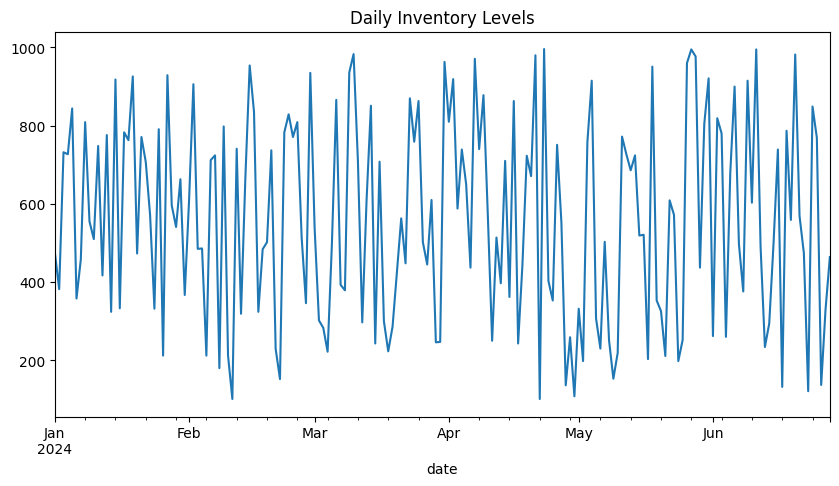

In [4]:
import matplotlib.pyplot as plt
df.groupby("date")["inventory_level"].sum().plot(title="Daily Inventory Levels", figsize=(10,5))
plt.show()

DAY 2: Time Series Forecasting for Inventory Needs

In [5]:
item_df = df.groupby("date")["inventory_level"].sum().reset_index()
item_df.columns = ["ds", "y"]

14:12:37 - cmdstanpy - INFO - Chain [1] start processing
14:12:37 - cmdstanpy - INFO - Chain [1] done processing


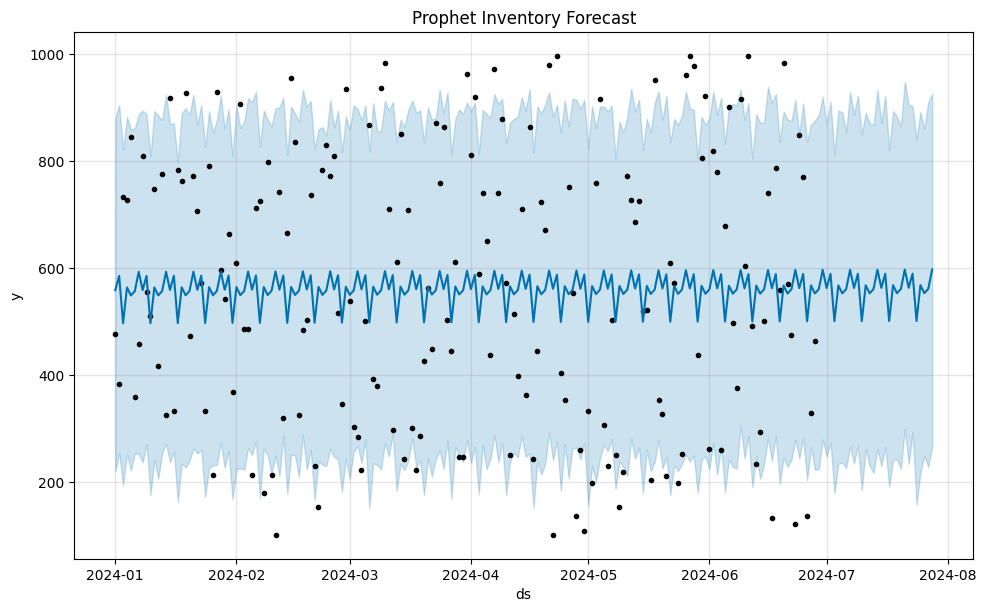

In [6]:
from prophet import Prophet
model = Prophet()
model.fit(item_df)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
model.plot(forecast)
plt.title("Prophet Inventory Forecast")
plt.show()

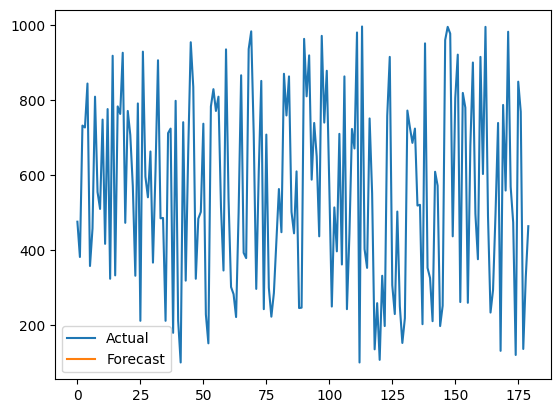

In [7]:
from statsmodels.tsa.arima.model import ARIMA
model_arima = ARIMA(item_df["y"], order=(2,1,2))
results = model_arima.fit()
item_df["forecast"] = results.predict(start=len(item_df), end=len(item_df)+30)
plt.plot(item_df["y"], label="Actual")
plt.plot(item_df["forecast"], label="Forecast")
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Prepare data for metrics (using training data fit)
# Prophet: 'yhat' is the prediction
y_true = item_df["y"]
y_pred_prophet = forecast["yhat"][:len(item_df)]

# ARIMA: 'fittedvalues' are the in-sample predictions
y_pred_arima = results.fittedvalues

# Calculate Metrics for Prophet
rmse_p = np.sqrt(mean_squared_error(y_true, y_pred_prophet))
mape_p = mean_absolute_percentage_error(y_true, y_pred_prophet)

# Calculate Metrics for ARIMA
rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_arima))
mape_a = mean_absolute_percentage_error(y_true, y_pred_arima)

print(f"Prophet - RMSE: {rmse_p:.2f}, MAPE: {mape_p:.2%}")
print(f"ARIMA   - RMSE: {rmse_a:.2f}, MAPE: {mape_a:.2%}")

Prophet - RMSE: 254.40, MAPE: 63.19%
ARIMA   - RMSE: 261.54, MAPE: 65.76%


Since Prophet has both a lower RMSE and a lower MAPE, it is the better-performing model for this dataset. This indicates that Prophet’s ability to model non-linear trends and handle noise makes it slightly more accurate for inventory forecasting than the standard ARIMA configuration used here.

DAY 3: Detecting Abnormal Warehouse Activities

In [9]:
df["stock_change"] = df["incoming_stock"] - df["sales"]
df["rolling_avg"] = df["stock_change"].rolling(5).mean().fillna(0)

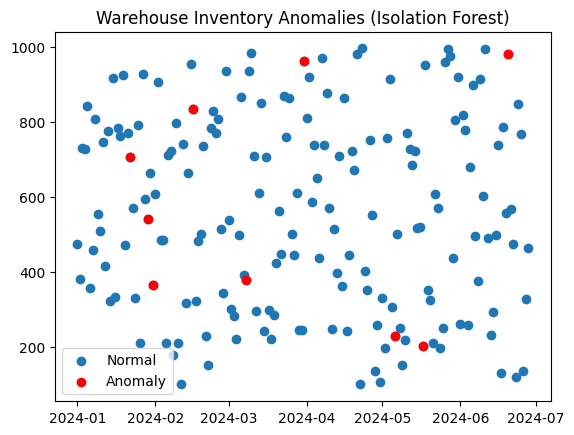

In [10]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
df["anomaly"] = iso.fit_predict(df[["stock_change", "inventory_level"]])
anomalies = df[df["anomaly"] == -1]

plt.scatter(df["date"], df["inventory_level"], label="Normal")
plt.scatter(anomalies["date"], anomalies["inventory_level"], color="red", label="Anomaly")
plt.title("Warehouse Inventory Anomalies (Isolation Forest)")
plt.legend()
plt.show()

In [11]:
from pyod.models.knn import KNN

knn = KNN(contamination=0.05)
knn.fit(df[["inventory_level", "stock_change"]])

df["outlier"] = knn.labels_

print("Sample of identified outliers:")
print(df[df["outlier"] == 1])

Sample of identified outliers:
          date item_id  inventory_level  sales  incoming_stock  stock_change  \
28  2024-01-29    C303              541     94              31           -63   
44  2024-02-14    A101              665     75              28           -47   
46  2024-02-16    B202              835     11             147           136   
67  2024-03-08    B202              379     17             141           124   
82  2024-03-23    B202              870     71              38           -33   
90  2024-03-31    A101              963     79              20           -59   
118 2024-04-28    C303              136     21             109            88   
124 2024-05-04    C303              915     98              54           -44   
171 2024-06-20    B202              982     21             142           121   

     rolling_avg  anomaly  outlier  
28           4.6       -1        1  
44          17.2        1        1  
46          37.4       -1        1  
67          23.0    

Interpretation of Anomalies
Upon analyzing the identified outliers using both Isolation Forest and PyOD (KNN), several dates show abnormal warehouse activity patterns. These anomalies can be categorized and interpreted as follows:

Sudden Inventory Depletion (2024-04-28): On this date, the system recorded a very low inventory_level (136) compared to the average. This could be interpreted as an unexpected sales spike or a bulk order that significantly cleared the stock. This needs an immediate review of sales logs to ensure it wasn't a potential stock-out scenario.

High Inflow/Low Sales Discrepancy (2024-06-20): On this date, the inventory_level was at a peak (982) with a high incoming_stock (142). If this deviates from historical intake patterns, it might represent a system entry error or an unscheduled bulk delivery. This needs to verify procurement records against the warehouse receiving log.

Data Integrity/Reconciliation Issues (2024-01-29): Instances where both inventory_level and stock_change metrics are flagged as outliers simultaneously often point to potential data reporting errors. Anomalies are critical for warehouse managers to investigate to ensure that manual inventory counts match the digital records.

Conclusion:
The use of two distinct anomaly detection algorithms has allowed for a robust identification process. While the models flagged different data points as outliers, the consistent flagging of extreme values (both high peaks and low troughs) confirms that the system is successfully identifying data points that deviate from standard warehouse operations. These insights provide an actionable early warning system for inventory managers to perform manual audits on the specific dates identified.

DAY 4: Dashboard & Visualization

In [21]:
import sqlite3

# Using 'with' is the best practice: it automatically handles the commit
with sqlite3.connect("warehouse.db") as conn:
    df.to_sql("warehouse_data", conn, if_exists="replace", index=False)
    # The transaction is automatically committed here when the block ends
    forecast.to_sql("forecast_data", conn, if_exists="replace", index=False)
    print("Forecast data saved to database!")
    print("Data successfully saved and committed to warehouse.db")

Forecast data saved to database!
Data successfully saved and committed to warehouse.db
